In [1]:
from src import sph_cpp
from src.visualization import *
import matplotlib.pyplot as plt

### Define simulation parameters

In [2]:
res = 0.5
no_steps = 100
Lx = 5.0
Ly = 5.0
rho0 = 1000.0
kappa = 1.2
v0 = 10
dt = 0.01
c_s = 0.1
gamma_index = 7.0
beta = 0.07

central_radius = 0.5
boundary_width = 0.1
max_force = 1000


### Run simulation

In [4]:
params = sph_cpp.SimulationParams(
    res, no_steps, Lx, Ly, rho0, kappa, v0, dt, c_s, beta, central_radius, boundary_width, max_force
)

# Initialize ParticleList
particle_list = sph_cpp.ParticleList(params)

# Setup initial conditions
particle_list.init_random()
particle_list.init_mass()
particle_list.init_vel()

# Run simulation
particle_list.integrate()

masses = np.array([params.rho0*params.res**2]*params.init_particles)

### Read data

In [5]:
positions, velocities = read_all_output("all_output.bin")

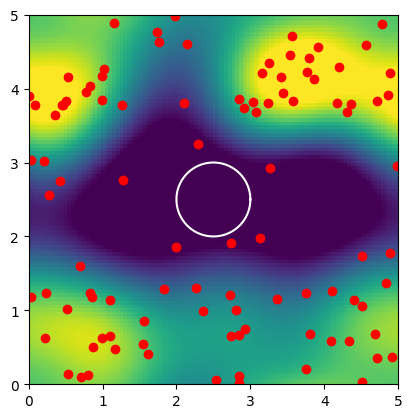

In [6]:
animate(positions, params, masses)